# ETL Pipeline - Olist E-Commerce (Big Data Project)

In [5]:
import os, sys, logging
from datetime import datetime

PYTHON_PATH = "C:/Users/Admin/AppData/Local/Programs/Python/Python312/python.exe"
os.environ["PYSPARK_PYTHON"] = PYTHON_PATH
os.environ["PYSPARK_DRIVER_PYTHON"] = PYTHON_PATH
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["TZ"] = "UTC"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("OlistETL")


Khởi tạo SparkSession

In [6]:
spark = (
    SparkSession.builder
    .appName("Olist_ETL_Pipeline")
    .master("local[4]")
    .config("spark.driver.memory", "4g")
    .config("spark.driver.maxResultSize", "1g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.ui.enabled", "false")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.pyspark.python", PYTHON_PATH)
    .config("spark.pyspark.driver.python", PYTHON_PATH)
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.network.timeout", "800s")
    .config("spark.executor.heartbeatInterval", "60s")
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("SparkSession OK -", spark.version)


SparkSession OK - 3.5.1


In [7]:
HDFS_BRONZE = "hdfs://localhost:9000/user/bigdata/olist/bronze"
HDFS_SILVER = "hdfs://localhost:9000/user/bigdata/olist/silver"
HDFS_GOLD   = "hdfs://localhost:9000/user/bigdata/olist/gold"


## 1. Đọc dữ liệu thô từ HDFS

In [8]:
csv_files = {
    "orders":       "orders/olist_orders_dataset.csv",
    "order_items":  "order_items/olist_order_items_dataset.csv",
    "payments":     "order_payments/olist_order_payments_dataset.csv",
    "reviews":      "order_reviews/olist_order_reviews_dataset.csv",
    "customers":    "customers/olist_customers_dataset.csv",
    "products":     "products/olist_products_dataset.csv",
    "sellers":      "sellers/olist_sellers_dataset.csv",
    "geolocation":  "geolocation/olist_geolocation_dataset.csv",
    "category_translation": "category_translation/product_category_name_translation.csv",
}

dataframes = {}
summary_rows = []
for name, filename in csv_files.items():
    path = f"{HDFS_BRONZE}/{filename}"
    df = (
        spark.read
        .option("header", "true")
        .option("inferSchema", "true")
        .option("encoding", "UTF-8")
        .csv(path)
    )
    dataframes[name] = df
    summary_rows.append({"table": name, "rows": df.count(), "columns": len(df.columns)})
    print(f"-> {name}: {summary_rows[-1]['rows']:,} dòng, {summary_rows[-1]['columns']} cột")

pd.DataFrame(summary_rows)


-> orders: 99,441 dòng, 8 cột
-> order_items: 112,650 dòng, 7 cột
-> payments: 103,886 dòng, 5 cột
-> reviews: 104,162 dòng, 7 cột
-> customers: 99,441 dòng, 5 cột
-> products: 32,951 dòng, 9 cột
-> sellers: 3,095 dòng, 4 cột
-> geolocation: 1,000,163 dòng, 5 cột
-> category_translation: 71 dòng, 2 cột


,table,rows,columns
0,orders,99441,8
1,order_items,112650,7
2,payments,103886,5
3,reviews,104162,7
4,customers,99441,5
5,products,32951,9
6,sellers,3095,4
7,geolocation,1000163,5
8,category_translation,71,2


Kiểm tra nhanh schema và vài dòng mẫu của bảng `orders`

In [9]:
dataframes["orders"].printSchema()
dataframes["orders"].limit(5).toPandas()


root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 17:56:33,2017-10-02 18:07:15,2017-10-05 02:55:00,2017-10-11 04:25:13,2017-10-18 07:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-25 03:41:37,2018-07-26 10:24:27,2018-07-26 21:31:00,2018-08-07 22:27:45,2018-08-13 07:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 15:38:49,2018-08-08 15:55:23,2018-08-08 20:50:00,2018-08-18 01:06:29,2018-09-04 07:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-19 02:28:06,2017-11-19 02:45:59,2017-11-22 20:39:59,2017-12-02 07:28:42,2017-12-15 07:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-14 04:18:39,2018-02-14 05:20:29,2018-02-15 02:46:34,2018-02-17 01:17:02,2018-02-26 07:00:00


Trực quan số dòng của từng bảng

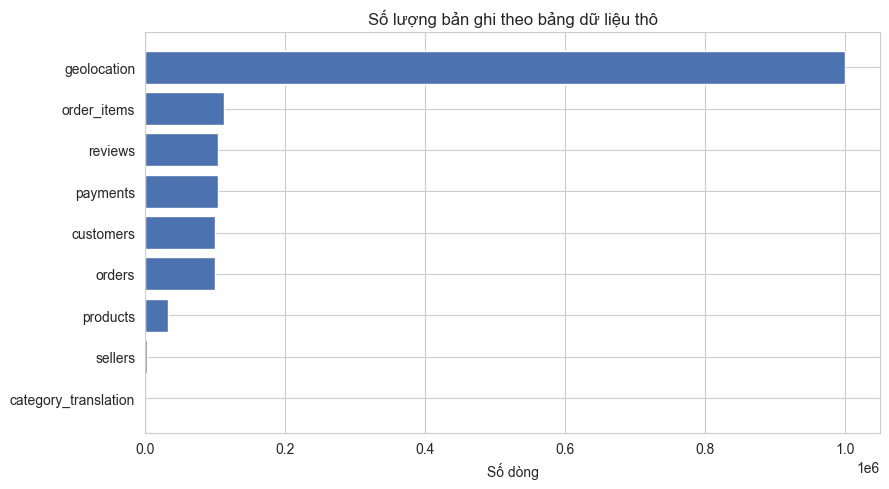

In [10]:
summary_df = pd.DataFrame(summary_rows).sort_values("rows", ascending=True)
plt.figure(figsize=(9, 5))
plt.barh(summary_df["table"], summary_df["rows"], color="#4C72B0")
plt.xlabel("Số dòng")
plt.title("Số lượng bản ghi theo bảng dữ liệu thô")
plt.tight_layout()
plt.show()


## 2. Join tất cả bảng thành `merged_orders`

2a. Tổng hợp payments theo order_id

In [11]:
payments_agg = (
    dataframes["payments"]
    .groupBy("order_id")
    .agg(
        F.sum("payment_value").alias("total_payment_value"),
        F.max("payment_installments").alias("max_installments"),
        F.count("*").alias("payment_count"),
        F.first("payment_type").alias("payment_type"),
        F.collect_set("payment_type").alias("payment_types_used"),
    )
)
print(f"payments_agg: {payments_agg.count():,} dòng")
payments_agg.limit(5).toPandas()


payments_agg: 99,440 dòng


,order_id,total_payment_value,max_installments,payment_count,payment_type,payment_types_used
0,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card,[credit_card]
1,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card,[credit_card]
2,0005f50442cb953dcd1d21e1fb923495,65.39,1,1,credit_card,[credit_card]
3,00061f2a7bc09da83e415a52dc8a4af1,68.87,3,1,credit_card,[credit_card]
4,00063b381e2406b52ad429470734ebd5,57.98,5,1,credit_card,[credit_card]


2b. Tổng hợp reviews theo order_id

In [12]:
reviews_agg = (
    dataframes["reviews"]
    .groupBy("order_id")
    .agg(
        F.avg("review_score").alias("review_score"),
        F.first("review_comment_title").alias("review_comment_title"),
        F.first("review_comment_message").alias("review_comment_message"),
        F.first("review_creation_date").alias("review_creation_date"),
        F.count("*").alias("review_count"),
    )
)
print(f"reviews_agg: {reviews_agg.count():,} dòng")
reviews_agg.limit(5).toPandas()


reviews_agg: 99,743 dòng


,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_count
0,"ATÉ UMA TV DE 4""",NaN,2018-04-26 08:29:17,None,None,1
1,FUI MUITO CLARO,NaN,2018-06-09 00:00:00,2018-06-09 09:34:50,None,1
2,"Mas a informação era até o dia 19 de março """,NaN,2018-03-10 12:17:50,None,None,1
3,"a entrega deve ser de uma única vez.""",NaN,2018-07-28 02:36:10,None,None,1
4,achei estranho o envelope estar rasgado,NaN,None,None,None,1


2c. Dịch tên danh mục sản phẩm sang tiếng Anh

In [13]:
products_translated = dataframes["products"].join(
    dataframes["category_translation"], on="product_category_name", how="left"
)
products_translated.limit(5).toPandas()


,product_category_name,product_id,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,perfumaria,1e9e8ef04dbcff4541ed26657ea517e5,40,287,1,225,16,10,14,perfumery
1,artes,3aa071139cb16b67ca9e5dea641aaa2f,44,276,1,1000,30,18,20,art
2,esporte_lazer,96bd76ec8810374ed1b65e291975717f,46,250,1,154,18,9,15,sports_leisure
3,bebes,cef67bcfe19066a932b7673e239eb23d,27,261,1,371,26,4,26,baby
4,utilidades_domesticas,9dc1a7de274444849c219cff195d0b71,37,402,4,625,20,17,13,housewares


2d-2e. Join order_items với products, sellers rồi tổng hợp theo order_id

In [14]:
items_with_products = dataframes["order_items"].join(
    products_translated, on="product_id", how="left"
)

items_with_sellers = items_with_products.join(
    dataframes["sellers"].select(
        F.col("seller_id"), F.col("seller_city"),
        F.col("seller_state"), F.col("seller_zip_code_prefix"),
    ),
    on="seller_id", how="left"
)

items_agg = (
    items_with_sellers
    .groupBy("order_id")
    .agg(
        F.count("*").alias("total_items"),
        F.sum("price").alias("total_price"),
        F.sum("freight_value").alias("total_freight_value"),
        F.countDistinct("product_id").alias("unique_products"),
        F.countDistinct("seller_id").alias("unique_sellers"),
        F.first("product_category_name_english").alias("main_category_english"),
        F.first("product_category_name").alias("main_category"),
        F.first("seller_city").alias("seller_city"),
        F.first("seller_state").alias("seller_state"),
        F.avg("product_weight_g").alias("avg_product_weight_g"),
        F.avg("product_length_cm").alias("avg_product_length_cm"),
        F.avg("product_height_cm").alias("avg_product_height_cm"),
        F.avg("product_width_cm").alias("avg_product_width_cm"),
        F.avg("product_photos_qty").alias("avg_product_photos_qty"),
    )
)
print(f"items_agg: {items_agg.count():,} dòng")
items_agg.limit(5).toPandas()


items_agg: 98,666 dòng


,order_id,total_items,total_price,total_freight_value,unique_products,unique_sellers,main_category_english,main_category,seller_city,seller_state,avg_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,avg_product_photos_qty
0,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,1,1,furniture_decor,moveis_decoracao,borda da mata,MG,3050.0,33.0,13.0,33.0,2.0
1,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,1,1,garden_tools,ferramentas_jardim,loanda,PR,3750.0,35.0,40.0,30.0,1.0
2,0005f50442cb953dcd1d21e1fb923495,1,53.99,11.40,1,1,books_technical,livros_tecnicos,sao paulo,SP,850.0,29.0,3.0,21.0,1.0
3,00061f2a7bc09da83e415a52dc8a4af1,1,59.99,8.88,1,1,health_beauty,beleza_saude,santo andre,SP,950.0,35.0,25.0,20.0,1.0
4,00063b381e2406b52ad429470734ebd5,1,45.00,12.98,1,1,fashion_bags_accessories,fashion_bolsas_e_acessorios,sao paulo,SP,200.0,16.0,16.0,11.0,1.0


2f. Join chính: orders → customers → items_agg → payments_agg → reviews_agg

In [15]:
merged = (
    dataframes["orders"]
    .join(dataframes["customers"], on="customer_id", how="left")
    .join(items_agg, on="order_id", how="left")
    .join(payments_agg, on="order_id", how="left")
    .join(reviews_agg, on="order_id", how="left")
)

print(f"merged: {merged.count():,} dòng, {len(merged.columns)} cột")
print("Danh sách cột:", merged.columns)
merged.printSchema()


merged: 99,441 dòng, 36 cột
Danh sách cột: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_items', 'total_price', 'total_freight_value', 'unique_products', 'unique_sellers', 'main_category_english', 'main_category', 'seller_city', 'seller_state', 'avg_product_weight_g', 'avg_product_length_cm', 'avg_product_height_cm', 'avg_product_width_cm', 'avg_product_photos_qty', 'total_payment_value', 'max_installments', 'payment_count', 'payment_type', 'payment_types_used', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_count']
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)

In [16]:
merged.limit(5).toPandas()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,total_payment_value,max_installments,payment_count,payment_type,payment_types_used,review_score,review_comment_title,review_comment_message,review_creation_date,review_count
0,07d9d11b0175952638ddd53d7855f8a7,a1c779cddccf5ffe60e543d3ce0dc477,delivered,2017-11-22 23:40:23,2017-11-22 23:48:33,2017-11-29 02:48:46,2017-11-30 20:49:03,2017-12-04 07:00:00,12e7867bb47d014edf9f37ce4c609621,1227,...,87.00,1,1,credit_card,[credit_card],5.0,None,Compro varias vezes da lannister.com. Sempre s...,2017-12-01 00:00:00,1
1,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 15:38:49,2018-08-08 15:55:23,2018-08-08 20:50:00,2018-08-18 01:06:29,2018-09-04 07:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,3,1,credit_card,[credit_card],5.0,None,None,2018-08-18 00:00:00,1
2,aa22c8b8e14d747a83a7a8876837fc82,3cdc0173943f051e46d6f1d616a70609,delivered,2017-08-13 05:35:47,2017-08-13 05:50:14,2017-08-15 22:52:33,2017-08-24 02:09:47,2017-09-08 07:00:00,c4555c8838fd8c5584ed2d818124f16a,83323,...,104.37,3,1,credit_card,[credit_card],5.0,None,Chegou bem antes do prazo e era exatamente o q...,2017-08-24 00:00:00,1
3,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-14 04:18:39,2018-02-14 05:20:29,2018-02-15 02:46:34,2018-02-17 01:17:02,2018-02-26 07:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,28.62,1,1,credit_card,[credit_card],5.0,None,None,2018-02-17 00:00:00,1
4,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 17:56:33,2017-10-02 18:07:15,2017-10-05 02:55:00,2017-10-11 04:25:13,2017-10-18 07:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,38.71,1,3,credit_card,"[credit_card, voucher]",4.0,None,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,1


## 3. Kiểm tra và làm sạch dữ liệu

Kiểm tra trùng lặp và giá trị null trước khi làm sạch

In [17]:
initial_count = merged.count()
dup_count = initial_count - merged.dropDuplicates(["order_id"]).count()
print(f"Tổng dòng: {initial_count:,} | Trùng lặp theo order_id: {dup_count:,}")

null_counts = {}
for c in merged.columns:
    n = merged.filter(F.col(c).isNull()).count()
    if n > 0:
        null_counts[c] = n

null_df = pd.DataFrame(list(null_counts.items()), columns=["column", "null_count"])
null_df["null_pct"] = round(null_df["null_count"] / initial_count * 100, 2)
null_df = null_df.sort_values("null_count", ascending=False)
null_df


Tổng dòng: 99,441 | Trùng lặp theo order_id: 0


,column,null_count,null_pct
23,review_comment_title,87890,88.38
24,review_comment_message,58656,58.99
25,review_creation_date,4589,4.61
2,order_delivered_customer_date,2965,2.98
8,main_category_english,2214,2.23
9,main_category,2193,2.21
16,avg_product_photos_qty,2164,2.18
1,order_delivered_carrier_date,1783,1.79
14,avg_product_height_cm,791,0.80
12,avg_product_weight_g,791,0.80


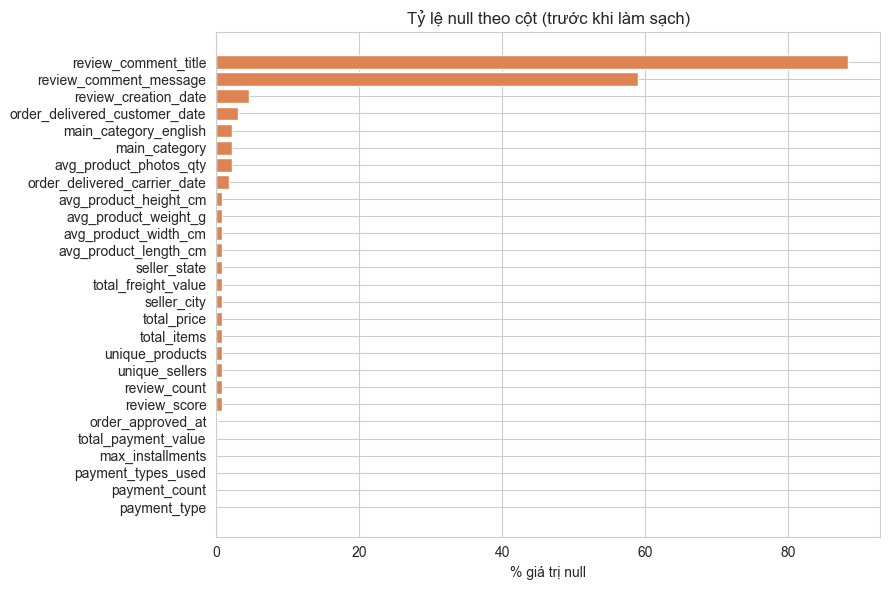

In [18]:
plt.figure(figsize=(9, 6))
plt.barh(null_df["column"], null_df["null_pct"], color="#DD8452")
plt.xlabel("% giá trị null")
plt.title("Tỷ lệ null theo cột (trước khi làm sạch)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


3a. Xóa bản ghi trùng lặp

In [19]:
merged = merged.dropDuplicates(["order_id"])
after_dedup = merged.count()
print(f"Đã xóa {initial_count - after_dedup:,} bản ghi trùng, còn lại {after_dedup:,} dòng")


Đã xóa 0 bản ghi trùng, còn lại 99,441 dòng


3b. Parse cột ngày tháng sang timestamp

In [20]:
date_columns = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for c in date_columns:
    if c in merged.columns:
        merged = merged.withColumn(c, F.to_timestamp(F.col(c), "yyyy-MM-dd HH:mm:ss"))
        print(f"Đã parse: {c}")


Đã parse: order_purchase_timestamp
Đã parse: order_approved_at
Đã parse: order_delivered_carrier_date
Đã parse: order_delivered_customer_date
Đã parse: order_estimated_delivery_date


3c. Điền giá trị mặc định cho các cột thiếu

In [21]:
numeric_fill = {
    "total_price": 0.0, "total_freight_value": 0.0, "total_payment_value": 0.0,
    "total_items": 0, "unique_products": 0, "unique_sellers": 0,
    "review_score": 0.0, "max_installments": 1, "payment_count": 0,
    "review_count": 0, "avg_product_weight_g": 0.0, "avg_product_length_cm": 0.0,
    "avg_product_height_cm": 0.0, "avg_product_width_cm": 0.0, "avg_product_photos_qty": 0.0,
}
merged = merged.fillna(numeric_fill)

string_fill = {
    "main_category_english": "unknown", "main_category": "desconhecido",
    "payment_type": "unknown", "review_comment_title": "",
    "review_comment_message": "", "seller_city": "unknown", "seller_state": "unknown",
}
merged = merged.fillna(string_fill)
print("Đã điền giá trị mặc định cho các cột số và chuỗi")


Đã điền giá trị mặc định cho các cột số và chuỗi


3d. Lọc bỏ đơn hàng không hợp lệ

Trước lọc: 99,441 dòng
Sau lọc:   99,277 dòng (đã loại 164)


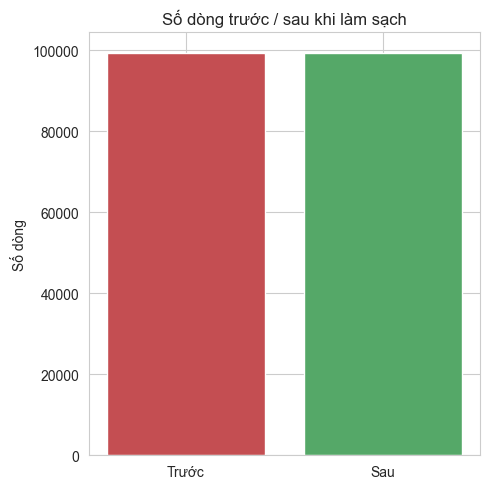

In [22]:
before_filter = merged.count()
merged = merged.filter(F.col("order_purchase_timestamp").isNotNull())
merged = merged.filter(
    (F.col("order_status") != "canceled") | (F.col("total_price") > 0)
)
after_filter = merged.count()

print(f"Trước lọc: {before_filter:,} dòng")
print(f"Sau lọc:   {after_filter:,} dòng (đã loại {before_filter - after_filter:,})")

plt.figure(figsize=(5, 5))
plt.bar(["Trước", "Sau"], [before_filter, after_filter], color=["#C44E52", "#55A868"])
plt.title("Số dòng trước / sau khi làm sạch")
plt.ylabel("Số dòng")
plt.tight_layout()
plt.show()


## 4. Feature Engineering

4a-4d. Thời gian giao hàng, chênh lệch dự kiến/thực tế, tỷ lệ phí ship, tổng giá trị đơn

In [23]:
merged = merged.withColumn(
    "delivery_days",
    F.when(
        F.col("order_delivered_customer_date").isNotNull(),
        F.datediff(F.col("order_delivered_customer_date"), F.col("order_purchase_timestamp"))
    ).otherwise(F.lit(None))
)

merged = merged.withColumn(
    "estimated_vs_actual",
    F.when(
        F.col("order_delivered_customer_date").isNotNull() &
        F.col("order_estimated_delivery_date").isNotNull(),
        F.datediff(F.col("order_estimated_delivery_date"), F.col("order_delivered_customer_date"))
    ).otherwise(F.lit(None))
)

merged = merged.withColumn(
    "freight_ratio",
    F.when(
        F.col("total_price") > 0,
        F.round(F.col("total_freight_value") / F.col("total_price"), 4)
    ).otherwise(F.lit(0.0))
)

merged = merged.withColumn("order_value", F.col("total_price") + F.col("total_freight_value"))
print("Đã tạo: delivery_days, estimated_vs_actual, freight_ratio, order_value")


Đã tạo: delivery_days, estimated_vs_actual, freight_ratio, order_value


4e. Các đặc trưng thời gian mua hàng

In [24]:
merged = (
    merged
    .withColumn("purchase_hour", F.hour("order_purchase_timestamp"))
    .withColumn("purchase_dayofweek", F.dayofweek("order_purchase_timestamp"))
    .withColumn("purchase_month", F.month("order_purchase_timestamp"))
    .withColumn("purchase_year", F.year("order_purchase_timestamp"))
    .withColumn("purchase_quarter", F.quarter("order_purchase_timestamp"))
    .withColumn("purchase_year_month", F.date_format("order_purchase_timestamp", "yyyy-MM"))
)
print("Đã tạo các đặc trưng thời gian")


Đã tạo các đặc trưng thời gian


4f-4g. Phân loại chất lượng giao hàng và mức độ hài lòng

In [25]:
merged = merged.withColumn(
    "delivery_status",
    F.when(F.col("estimated_vs_actual").isNull(), "not_delivered")
     .when(F.col("estimated_vs_actual") >= 0, "on_time")
     .otherwise("late")
)

merged = merged.withColumn(
    "satisfaction_level",
    F.when(F.col("review_score") >= 4, "satisfied")
     .when(F.col("review_score") == 3, "neutral")
     .when(F.col("review_score") >= 1, "dissatisfied")
     .otherwise("no_review")
)
print(f"Tổng số cột sau feature engineering: {len(merged.columns)}")


Tổng số cột sau feature engineering: 48


Trực quan các đặc trưng vừa tạo

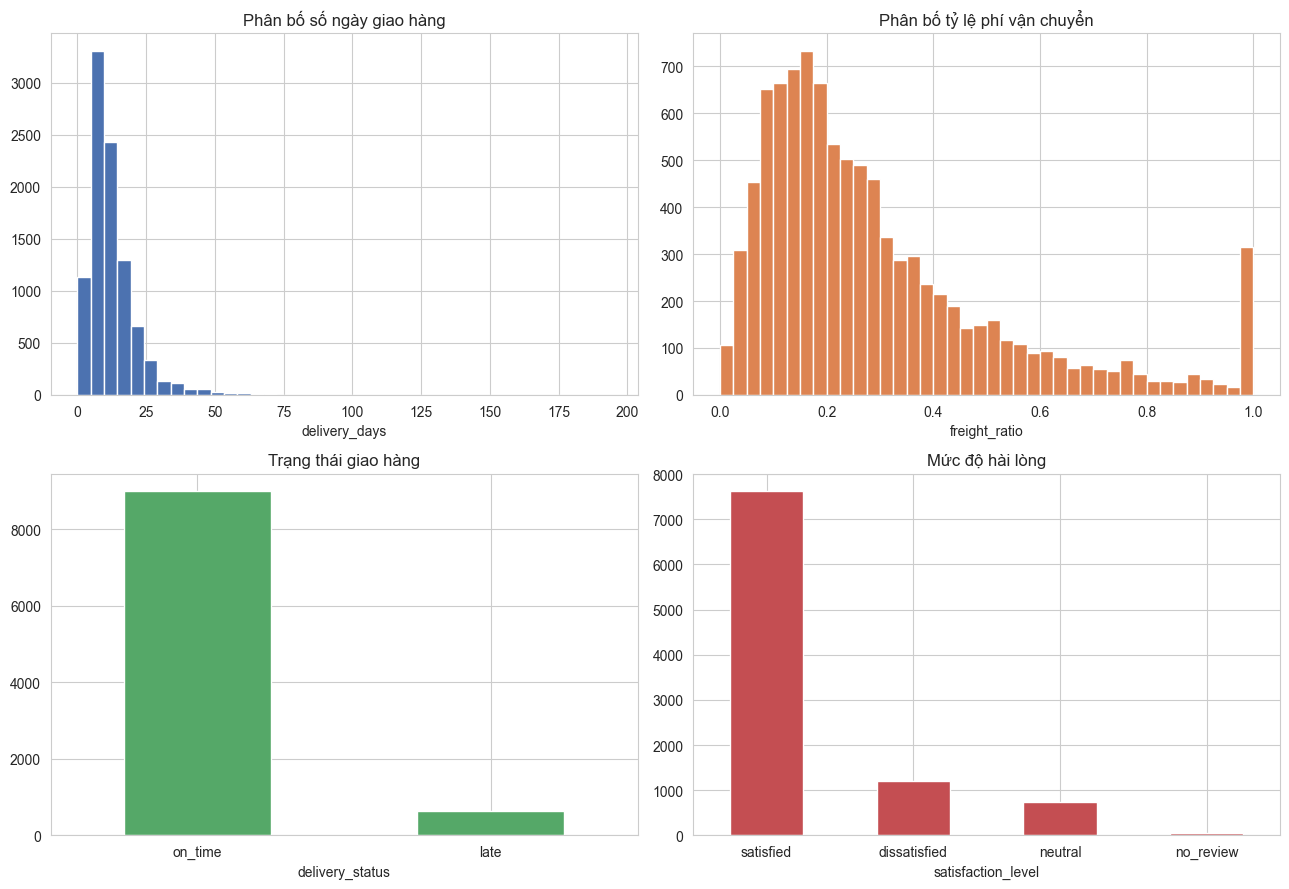

In [26]:
sample_pdf = merged.select(
    "delivery_days", "freight_ratio", "delivery_status", "satisfaction_level"
).dropna(subset=["delivery_days"]).sample(fraction=0.1, seed=42).limit(20000).toPandas()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(sample_pdf["delivery_days"], bins=40, color="#4C72B0")
axes[0, 0].set_title("Phân bố số ngày giao hàng")
axes[0, 0].set_xlabel("delivery_days")

axes[0, 1].hist(sample_pdf["freight_ratio"].clip(upper=1), bins=40, color="#DD8452")
axes[0, 1].set_title("Phân bố tỷ lệ phí vận chuyển")
axes[0, 1].set_xlabel("freight_ratio")

sample_pdf["delivery_status"].value_counts().plot(kind="bar", ax=axes[1, 0], color="#55A868")
axes[1, 0].set_title("Trạng thái giao hàng")
axes[1, 0].tick_params(axis="x", rotation=0)

sample_pdf["satisfaction_level"].value_counts().plot(kind="bar", ax=axes[1, 1], color="#C44E52")
axes[1, 1].set_title("Mức độ hài lòng")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 5. Tính RFM (Recency, Frequency, Monetary) theo khách hàng

In [27]:
delivered_orders = merged.filter(F.col("order_status") == "delivered")

max_date = delivered_orders.agg(F.max("order_purchase_timestamp")).collect()[0][0]
print(f"Ngày mốc (mua hàng gần nhất): {max_date}")

rfm_df = (
    delivered_orders
    .groupBy("customer_unique_id")
    .agg(
        F.datediff(F.lit(max_date), F.max("order_purchase_timestamp")).alias("recency"),
        F.countDistinct("order_id").alias("frequency"),
        F.sum("total_payment_value").alias("monetary"),
        F.avg("review_score").alias("avg_review_score"),
        F.avg("delivery_days").alias("avg_delivery_days"),
        F.avg("total_items").alias("avg_items_per_order"),
        F.first("customer_state").alias("customer_state"),
        F.first("customer_city").alias("customer_city"),
        F.max("order_purchase_timestamp").alias("last_purchase_date"),
        F.min("order_purchase_timestamp").alias("first_purchase_date"),
    )
)

rfm_df = rfm_df.withColumn(
    "customer_tenure_days",
    F.datediff(F.col("last_purchase_date"), F.col("first_purchase_date"))
)
print(f"Đã tính RFM cho {rfm_df.count():,} khách hàng")


Ngày mốc (mua hàng gần nhất): 2018-08-29 22:00:37
Đã tính RFM cho 93,358 khách hàng


Phân hạng RFM (1-4) bằng ntile

In [28]:
r_window = Window.orderBy(F.col("recency").asc())
f_window = Window.orderBy(F.col("frequency").desc())
m_window = Window.orderBy(F.col("monetary").desc())

rfm_df = (
    rfm_df
    .withColumn("r_score", F.ntile(4).over(r_window))
    .withColumn("f_score", F.ntile(4).over(f_window))
    .withColumn("m_score", F.ntile(4).over(m_window))
)
rfm_df = rfm_df.withColumn("rfm_score", F.col("r_score") + F.col("f_score") + F.col("m_score"))

rfm_df.select("recency", "frequency", "monetary", "rfm_score").describe().toPandas()


,summary,recency,frequency,monetary,rfm_score
0,count,93358,93358,93358,93358
1,mean,237.47887701107564,1.0334197390689603,165.19700261358162,7.499935731271021
2,stddev,152.5950542957237,0.20909743968188677,226.31401249105576,2.505517331830654
3,min,0,1,0.0,3
4,max,713,15,13664.08,12


Trực quan phân bố RFM

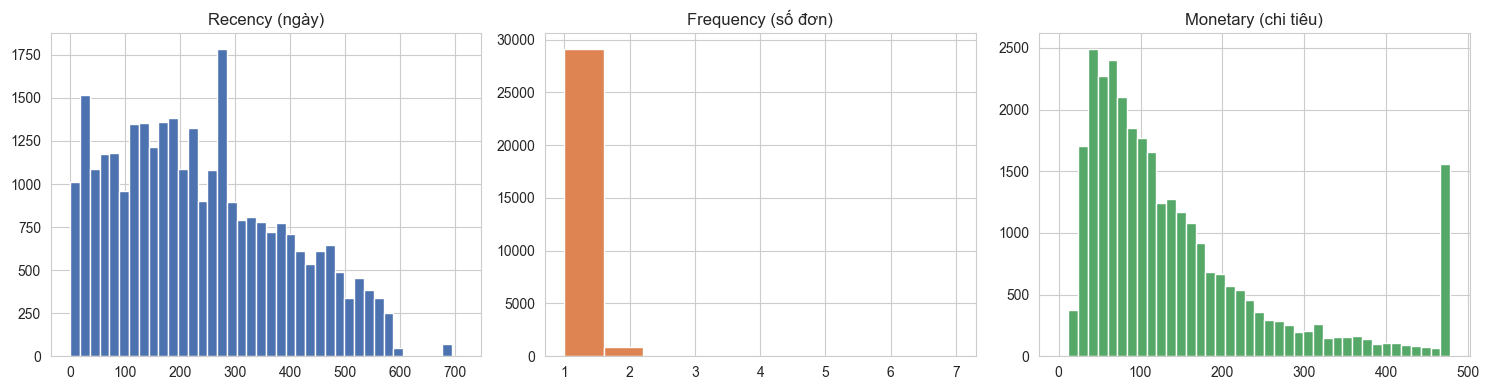

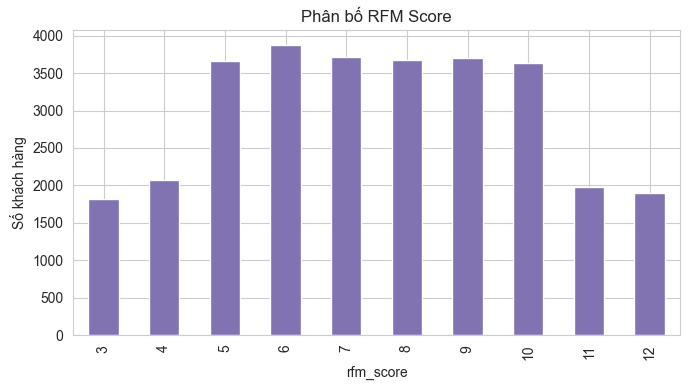

In [29]:
rfm_pdf = rfm_df.select("recency", "frequency", "monetary", "rfm_score").sample(
    fraction=min(1.0, 30000 / rfm_df.count()), seed=42
).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(rfm_pdf["recency"], bins=40, color="#4C72B0")
axes[0].set_title("Recency (ngày)")

axes[1].hist(rfm_pdf["frequency"].clip(upper=10), bins=10, color="#DD8452")
axes[1].set_title("Frequency (số đơn)")

axes[2].hist(rfm_pdf["monetary"].clip(upper=rfm_pdf["monetary"].quantile(0.95)), bins=40, color="#55A868")
axes[2].set_title("Monetary (chi tiêu)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
rfm_pdf["rfm_score"].value_counts().sort_index().plot(kind="bar", color="#8172B2")
plt.title("Phân bố RFM Score")
plt.xlabel("rfm_score")
plt.ylabel("Số khách hàng")
plt.tight_layout()
plt.show()


Join RFM ngược lại vào `merged`

In [30]:
merged = merged.join(
    rfm_df.select(
        "customer_unique_id", "recency", "frequency", "monetary",
        "r_score", "f_score", "m_score", "rfm_score",
        "avg_review_score", "avg_delivery_days", "customer_tenure_days",
    ),
    on="customer_unique_id", how="left"
)
print(f"merged sau khi join RFM: {len(merged.columns)} cột")


merged sau khi join RFM: 58 cột


## 6. Tạo nhãn Churn

In [31]:
max_date_churn = merged.agg(F.max("order_purchase_timestamp")).collect()[0][0]
print(f"Ngày mốc: {max_date_churn} | Ngưỡng churn: 90 ngày không mua hàng")

merged = merged.withColumn("churn", F.when(F.col("recency") > 90, 1).otherwise(0))

churn_pdf = merged.groupBy("churn").count().toPandas()
total = churn_pdf["count"].sum()
churn_pdf["pct"] = round(churn_pdf["count"] / total * 100, 2)
churn_pdf


Ngày mốc: 2018-09-03 16:06:57 | Ngưỡng churn: 90 ngày không mua hàng


,churn,count,pct
0,1,77369,77.93
1,0,21908,22.07


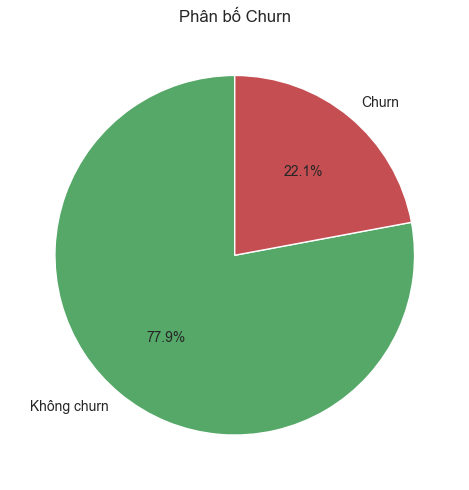

In [32]:
plt.figure(figsize=(5, 5))
plt.pie(
    churn_pdf["count"], labels=["Không churn", "Churn"],
    autopct="%1.1f%%", colors=["#55A868", "#C44E52"], startangle=90
)
plt.title("Phân bố Churn")
plt.tight_layout()
plt.show()


## 7. Kiểm tra dữ liệu cuối cùng

In [33]:
def validate_dataframe_schema(df, expected_columns, label):
    actual_cols = set(df.columns)
    missing = set(expected_columns) - actual_cols
    if missing:
        raise ValueError(f"Schema validation FAILED cho {label}: thiếu cột {missing}")
    row_count = df.count()
    print(f"Schema validation PASSED cho {label}: {len(actual_cols)} cột, {row_count:,} dòng")

validate_dataframe_schema(
    merged,
    ["order_id", "customer_unique_id", "total_price", "delivery_days", "review_score", "order_status"],
    "merged_orders (Silver)"
)
validate_dataframe_schema(
    rfm_df,
    ["customer_unique_id", "recency", "frequency", "monetary", "r_score", "f_score", "m_score"],
    "rfm_customers (Gold)"
)


Schema validation PASSED cho merged_orders (Silver): 59 cột, 99,277 dòng
Schema validation PASSED cho rfm_customers (Gold): 16 cột, 93,358 dòng


In [34]:
merged.printSchema()


root
 |-- customer_unique_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- total_items: long (nullable = false)
 |-- total_price: double (nullable = false)
 |-- total_freight_value: double (nullable = false)
 |-- unique_products: long (nullable = false)
 |-- unique_sellers: long (nullable = false)
 |-- main_category_english: string (nullable = false)
 |-- main_category: string (nullable = false)
 |-- seller_city: string (nullable = fa

In [35]:
merged.select(
    "order_id", "customer_unique_id", "order_status", "total_price",
    "delivery_days", "review_score", "recency", "frequency", "monetary", "churn"
).limit(10).toPandas()


,order_id,customer_unique_id,order_status,total_price,delivery_days,review_score,recency,frequency,monetary,churn
0,0005f50442cb953dcd1d21e1fb923495,0782c41380992a5a533489063df0eef6,delivered,53.99,2,4.0,58,1,65.39,0
1,00061f2a7bc09da83e415a52dc8a4af1,107e6259485efac66428a56f10801f4f,delivered,59.99,5,5.0,158,1,68.87,1
2,00063b381e2406b52ad429470734ebd5,3fb97204945ca0c01bcf3eee6031c5f1,delivered,45.00,11,5.0,33,1,57.98,0
3,000f25f4d72195062c040b12dce9a18a,1a6cbc34ea404cb0af7ed74df0999354,delivered,119.99,15,4.0,175,1,164.39,1
4,001021efaa8636c29475e7734483457d,2193383c470dc9cec894ce78afd0ebd6,delivered,49.00,9,4.0,183,1,64.10,1
5,0011d82c4b53e22e84023405fb467e57,02daaa0e021d624d1784c4ea5cc84ace,delivered,289.00,10,4.0,225,1,315.33,1
6,00130c0eee84a3d909e75bc08c5c3ca1,b5910f24d2483d697b37e3857b621061,delivered,27.90,2,5.0,79,1,35.84,0
7,0017afd5076e074a48f1f1a4c7bac9c5,98758d88bf4b8eef1372ddee45d63178,delivered,809.10,47,1.0,346,2,997.96,1
8,001dbc16dc51075e987543d23a0507c7,c6f624cf0e9908fe310d59a80350bea0,delivered,69.90,16,5.0,578,1,87.90,1
9,00276d5c3491fbf55305e26891040df9,af11903c9def1d99643292e8d695b212,delivered,44.90,31,4.0,197,1,68.12,1


## 8. Lưu dữ liệu lên HDFS

In [36]:
def verify_hdfs_write(spark, hdfs_path, label):
    try:
        check_df = spark.read.parquet(hdfs_path)
        count = check_df.count()
        if count == 0:
            raise RuntimeError(f"{hdfs_path} rỗng sau khi ghi.")
        print(f"Xác nhận {label}: đọc lại được {count:,} dòng. OK.")
        return True
    except Exception as e:
        print(f"XÁC NHẬN THẤT BẠI cho {label}: {e}")
        return False


In [37]:
merged_path = f"{HDFS_SILVER}/merged_orders"
merged.coalesce(4).write.mode("overwrite").parquet(merged_path)
print(f"Đã ghi merged_orders -> {merged_path}")
verify_hdfs_write(spark, merged_path, "merged_orders")


Đã ghi merged_orders -> hdfs://localhost:9000/user/bigdata/olist/silver/merged_orders
Xác nhận merged_orders: đọc lại được 99,277 dòng. OK.


True

In [38]:
rfm_path = f"{HDFS_GOLD}/rfm_customers"
rfm_df.coalesce(2).write.mode("overwrite").parquet(rfm_path)
print(f"Đã ghi rfm_customers -> {rfm_path}")
verify_hdfs_write(spark, rfm_path, "rfm_customers")


Đã ghi rfm_customers -> hdfs://localhost:9000/user/bigdata/olist/gold/rfm_customers
Xác nhận rfm_customers: đọc lại được 93,358 dòng. OK.


True

Tổng kết pipeline

In [39]:
print("=" * 60)
print("ETL PIPELINE HOÀN THÀNH")
print(f"Merged orders: {merged.count():,} dòng, {len(merged.columns)} cột")
print(f"RFM customers: {rfm_df.count():,} dòng")
print(f"Silver: {HDFS_SILVER}")
print(f"Gold:   {HDFS_GOLD}")
print("=" * 60)


ETL PIPELINE HOÀN THÀNH
Merged orders: 99,277 dòng, 59 cột
RFM customers: 93,358 dòng
Silver: hdfs://localhost:9000/user/bigdata/olist/silver
Gold:   hdfs://localhost:9000/user/bigdata/olist/gold


In [40]:
spark.stop()
print("SparkSession đã dừng.")


SparkSession đã dừng.
